APRENDIZAJE SUPERVISADO - IMPLEMENTACION DE RANDOM FOREST

In [ ]:
import pandas as pd
import numpy as np

# Nombres de las columnas para las características morfológicas
feature_cols_detailed = [
    'diametro_ecuatorial_um',      # Diámetro en micrómetros
    'diametro_polar_um',           # Diámetro polar en micrómetros
    'forma_general',               # Categórica: esferica, prolata, oblata, etc.
    'num_aperturas',               # Número de aperturas
    'tipo_apertura',               # Categórica: porado, colpado, colporado, sulcado, etc.
    'ornamentacion_exina',         # Categórica: psilado, reticulado, equinado, verrucoso, etc.
    'densidad_ornamentacion',      # Numérica: ej. 1-5 para intensidad o densidad de la ornamentación
    'espesor_exina_um',            # Espesor de la exina en micrómetros
    'simetria',                    # Categórica: radial, bilateral, asimetrica
    'presencia_saccos',            # Booleana: 0 o 1 (No/Si)
    'taxon_nombre'                 # Variable objetivo: Nombre del taxón
]

# Nombres de taxones de ejemplo (ajusta esto a tus palinomorfos reales de Salta)
palynomorph_taxa_salta = [
    'Alnus sp.',
    'Podocarpus sp.',
    'Nothofagidites sp.',
    'Ephedra sp.',
    'Poaceae indet.',
    'Asteraceae indet.',
    'Chenopodiaceae/Amaranthaceae type',
    'Cyatheaceae/Dicksoniaceae type' # Espora
]

# Generar datos de ejemplo para 250 palinomorfos con mayor variedad
data_detailed = {
    'diametro_ecuatorial_um': np.random.uniform(10, 80, 250).round(1),
    'diametro_polar_um': np.random.uniform(8, 70, 250).round(1),
    'forma_general': np.random.choice(['esferica', 'prolata', 'oblata', 'subesferica', 'triangular'], 250),
    'num_aperturas': np.random.randint(0, 6, 250), # 0 para esporas o inaperturados
    'tipo_apertura': np.random.choice(['porado', 'colpado', 'colporado', 'sulcado', 'inaperturado', 'ulcerado'], 250),
    'ornamentacion_exina': np.random.choice(['psilado', 'reticulado', 'equinado', 'verrucoso', 'escabrado', 'foveolado'], 250),
    'densidad_ornamentacion': np.random.uniform(1, 5, 250).round(1), # Escala de 1 a 5
    'espesor_exina_um': np.random.uniform(0.5, 5.0, 250).round(1),
    'simetria': np.random.choice(['radial', 'bilateral', 'asimetrica'], 250),
    'presencia_saccos': np.random.choice([0, 1], 250),
    'taxon_nombre': np.random.choice(palynomorph_taxa_salta, 250)
}

df_template_detailed = pd.DataFrame(data_detailed)

# Ruta y nombre del archivo Excel a generar
excel_template_name = 'palinomorfos_template_detallado.xlsx'

# Guardar el DataFrame en un archivo Excel
df_template_detailed.to_excel(excel_template_name, index=False)

print(f"Se ha creado el archivo '{excel_template_name}' con un modelo de datos detallado.")
print("Primeras 5 filas del archivo modelo:")
print(df_template_detailed.head())
print("\nPara descargar el archivo, busca 'palinomorfos_template_detallado.xlsx' en el explorador de archivos de Colab (icono de carpeta a la izquierda) y haz clic derecho > Descargar.")
print("\nLuego, reemplaza los datos de ejemplo en este archivo con tus propios datos reales de palinomorfos del Cuaternario de Salta.")

Se ha creado el archivo 'palinomorfos_template_detallado.xlsx' con un modelo de datos detallado.
Primeras 5 filas del archivo modelo:
   diametro_ecuatorial_um  diametro_polar_um forma_general  num_aperturas  \
0                    21.6               39.4       prolata              1   
1                    66.6               42.6       prolata              5   
2                    28.5               47.0       prolata              3   
3                    15.5               17.9        oblata              0   
4                    56.7               67.3       prolata              0   

  tipo_apertura ornamentacion_exina  densidad_ornamentacion  espesor_exina_um  \
0        porado          reticulado                     1.2               2.0   
1       sulcado           verrucoso                     4.1               3.1   
2        porado             psilado                     1.5               1.5   
3       colpado           escabrado                     1.0               0.7  

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# =============================================================================
# FIX: Creating a dummy DataFrame 'df' for demonstration purposes
# This assumes your actual palynomorph data will have similar columns.
# REMINDER: You need to successfully load your actual data in the previous step.
# =============================================================================
# Dummy data for demonstration if 'df' was not loaded in the previous step
if 'df' not in locals():
    data = {
        'dimension_a': np.random.rand(100) * 10,
        'dimension_b': np.random.rand(100) * 8,
        'pore_count': np.random.randint(1, 5, 100),
        'texture_value': np.random.rand(100),
        'taxon_name': np.random.choice(['Palinomorfo_A', 'Palinomorfo_B', 'Palinomorfo_C'], 100)
    }
    df = pd.DataFrame(data)
    print("ADVERTENCIA: 'df' no estaba definido. Se creó un DataFrame de ejemplo para la demostración.")
    print("Por favor, asegúrate de haber cargado tus datos correctamente en el paso anterior.")

# =============================================================================
# PASO 1: INSPECCIONA TUS DATOS (si no lo has hecho ya)
# Ejecuta las siguientes líneas si necesitas recordar las columnas de tu df
print("Columnas del DataFrame df:")
print(df.columns)
print("Primeras 5 filas del DataFrame df:")
print(df.head())
# =============================================================================

# =============================================================================
# PASO 2 y 3: DEFINE TUS COLUMNAS DE CARACTERÍSTICAS Y LA COLUMNA OBJETIVO
# Reemplaza los nombres de las columnas con los reales de tu DataFrame 'df'.
# =============================================================================

# Ejemplo ajustado a nuestro dummy df o si tus columnas son similares:
feature_columns = ['dimension_a', 'dimension_b', 'pore_count', 'texture_value'] # <<-- MODIFICA ESTO con TUS columnas
target_column = 'taxon_name' # <<-- MODIFICA ESTO con TU columna objetivo

# =============================================================================
# PASO 4: SEPARA X Y Y
# =============================================================================
X = df[feature_columns]
y = df[target_column]

# =============================================================================
# PASO 5: CONVERTIR ETIQUETAS DE TEXTO A NUMÉRICAS (si es necesario)
# Si tu columna 'y' contiene texto (ej. nombres de taxones), descomenta
# y ejecuta la siguiente sección.
# Si 'y' ya es numérica, déjala comentada.
# =============================================================================
if y.dtype == 'object' or y.dtype.name == 'category': # Comprueba si las etiquetas son de tipo objeto/cadena
    print("Las etiquetas de la columna objetivo son de texto. Aplicando LabelEncoder...")
    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Labels convertidas a números:", le.classes_)
else:
    print("Las etiquetas de la columna objetivo ya son numéricas o de un tipo compatible.")

print("\nForma de X (Características):", X.shape)
print("Forma de y (Etiquetas):", y.shape)
print("\nPrimeras 5 filas de X:")
print(X.head())
print("\nPrimeras 5 etiquetas de y (después de la posible conversión):")
print(y[:5]) # Corrected to display first 5 elements of numpy array

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-2022912475.py", line 1, in <cell line: 0>
    from sklearn.preprocessing import LabelEncoder
  File "/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py", line 73, in <module>
    from .base import clone  # noqa: E402
    ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 19, in <module>
    from .utils._estimator_html_repr import _HTMLDocumentationLinkMixin, estimator_html_repr
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/__init__.py", line 15, in <module>
    from ._chunking import gen_batches, gen_even_slices
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_chunking.py", line 11, in <module>
    from ._param_validation import Interval, validate_params
  File "/usr/local/lib/python3.1

TypeError: object of type 'NoneType' has no len()

**Reasoning**:
The previous code failed because `y` became a NumPy array after `LabelEncoder` was applied, and NumPy arrays do not have a `.head()` method. I will replace `y.head()` with `y[:5]` to correctly display the first five elements of the NumPy array.



In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# =============================================================================
# FIX: Creating a dummy DataFrame 'df' for demonstration purposes
# This assumes your actual palynomorph data will have similar columns.
# REMINDER: You need to successfully load your actual data in the previous step.
# =============================================================================
# Dummy data for demonstration if 'df' was not loaded in the previous step
if 'df' not in locals():
    data = {
        'dimension_a': np.random.rand(100) * 10,
        'dimension_b': np.random.rand(100) * 8,
        'pore_count': np.random.randint(1, 5, 100),
        'texture_value': np.random.rand(100),
        'taxon_name': np.random.choice(['Palinomorfo_A', 'Palinomorfo_B', 'Palinomorfo_C'], 100)
    }
    df = pd.DataFrame(data)
    print("ADVERTENCIA: 'df' no estaba definido. Se creó un DataFrame de ejemplo para la demostración.")
    print("Por favor, asegúrate de haber cargado tus datos correctamente en el paso anterior.")

# =============================================================================
# PASO 1: INSPECCIONA TUS DATOS (si no lo has hecho ya)
# Ejecuta las siguientes líneas si necesitas recordar las columnas de tu df
print("Columnas del DataFrame df:")
print(df.columns)
print("Primeras 5 filas del DataFrame df:")
print(df.head())
# =============================================================================

# =============================================================================
# PASO 2 y 3: DEFINE TUS COLUMNAS DE CARACTERÍSTICAS Y LA COLUMNA OBJETIVO
# Reemplaza los nombres de las columnas con los reales de tu DataFrame 'df'.
# =============================================================================

# Ejemplo ajustado a nuestro dummy df o si tus columnas son similares:
feature_columns = ['dimension_a', 'dimension_b', 'pore_count', 'texture_value'] # <<-- MODIFICA ESTO con TUS columnas
target_column = 'taxon_name' # <<-- MODIFICA ESTO con TU columna objetivo

# =============================================================================
# PASO 4: SEPARA X Y Y
# =============================================================================
X = df[feature_columns]
y = df[target_column]

# =============================================================================
# PASO 5: CONVERTIR ETIQUETAS DE TEXTO A NUMÉRICAS (si es necesario)
# Si tu columna 'y' contiene texto (ej. nombres de taxones), descomenta
# y ejecuta la siguiente sección.
# Si 'y' ya es numérica, déjala comentada.
# =============================================================================
if y.dtype == 'object' or y.dtype.name == 'category': # Comprueba si las etiquetas son de tipo objeto/cadena
    print("Las etiquetas de la columna objetivo son de texto. Aplicando LabelEncoder...")
    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Labels convertidas a números:", le.classes_)
else:
    print("Las etiquetas de la columna objetivo ya son numéricas o de un tipo compatible.")

print("\nForma de X (Características):", X.shape)
print("Forma de y (Etiquetas):", y.shape)
print("\nPrimeras 5 filas de X:")
print(X.head())
print("\nPrimeras 5 etiquetas de y (después de la posible conversión):")
print(y[:5]) # Corrected to display first 5 elements of numpy array


Columnas del DataFrame df:
Index(['dimension_a', 'dimension_b', 'pore_count', 'texture_value',
       'taxon_name'],
      dtype='object')
Primeras 5 filas del DataFrame df:
   dimension_a  dimension_b  pore_count  texture_value     taxon_name
0     5.465034     7.695297           1       0.889061  Palinomorfo_B
1     7.522112     7.741137           4       0.836918  Palinomorfo_B
2     1.229827     1.639818           1       0.547765  Palinomorfo_C
3     0.209993     4.406346           3       0.698010  Palinomorfo_A
4     9.200125     3.310587           4       0.164349  Palinomorfo_A
Las etiquetas de la columna objetivo son de texto. Aplicando LabelEncoder...
Labels convertidas a números: ['Palinomorfo_A' 'Palinomorfo_B' 'Palinomorfo_C']

Forma de X (Características): (100, 4)
Forma de y (Etiquetas): (100,)

Primeras 5 filas de X:
   dimension_a  dimension_b  pore_count  texture_value
0     5.465034     7.695297           1       0.889061
1     7.522112     7.741137           4     

## Dividir Datos en Entrenamiento y Prueba

### Subtask:
Dividir los conjuntos de características (X) y etiquetas (y) en subconjuntos de entrenamiento y prueba utilizando `train_test_split`. Se recomienda usar `test_size=0.3` y `random_state=42` para reproducibilidad. Considera agregar `stratify=y` si tus clases de palinomorfos están desbalanceadas.


**Reasoning**:
The subtask requires splitting the data into training and testing sets using `train_test_split`, with specified parameters, and then verifying the split by printing the shapes of the resulting datasets.



In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos stratify=y para asegurar que la proporción de clases se mantenga en ambos conjuntos,
# lo cual es importante si las clases están desbalanceadas.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Datos divididos en entrenamiento y prueba:")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")

Datos divididos en entrenamiento y prueba:
Forma de X_train: (70, 4)
Forma de X_test: (30, 4)
Forma de y_train: (70,)
Forma de y_test: (30,)


## Escalar Características

### Subtask:
Aplicar `StandardScaler` a los datos de entrenamiento y prueba. Aunque Random Forest no es sensible al escalado, es una buena práctica y puede ser útil si experimentas con otros modelos en el futuro. Recuerda aplicar `fit_transform` al conjunto de entrenamiento y solo `transform` al conjunto de prueba.


**Reasoning**:
The subtask requires scaling the training and testing data using StandardScaler. I will import the necessary class, instantiate it, apply fit_transform to the training data, transform the test data, and then display the first few rows of the scaled data to verify the operation.



In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Crear una instancia de StandardScaler
scaler = StandardScaler()

# 2. Aplicar fit_transform al conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# 3. Aplicar transform al conjunto de prueba
X_test_scaled = scaler.transform(X_test)

print("Características de entrenamiento escaladas (primeras 5 filas):\n", X_train_scaled[:5])
print("\nCaracterísticas de prueba escaladas (primeras 5 filas):\n", X_test_scaled[:5])

Características de entrenamiento escaladas (primeras 5 filas):
 [[ 0.05114449 -1.41716798  1.13209786 -0.19278352]
 [-0.11560882 -0.50087101  1.13209786  0.56099999]
 [-1.38662057 -0.71051628 -1.50946382 -1.49606859]
 [-0.75430043  1.21521793 -1.50946382 -0.04826435]
 [-1.44527148 -0.95275634 -1.50946382  0.0438262 ]]

Características de prueba escaladas (primeras 5 filas):
 [[ 1.15808511 -1.42454359 -0.62894326  1.19112204]
 [-1.29337987  1.38142812 -0.62894326 -0.05337047]
 [ 1.08761795 -1.30114157 -0.62894326 -1.82371001]
 [ 1.52088089  0.30717327 -1.50946382 -1.3285542 ]
 [ 0.88594077  0.20188487 -0.62894326 -1.83227235]]


## Crear y Entrenar el Modelo Random Forest

### Subtask:
Instanciar el `RandomForestClassifier` con un número apropiado de estimadores (por ejemplo, `n_estimators=100`) y `random_state=42`. Luego, entrenar el modelo utilizando los datos de entrenamiento escalados (`X_train_scaled`, `y_train`).


**Reasoning**:
The subtask requires instantiating the RandomForestClassifier and training it with the scaled training data. I will import the necessary class, create an instance with the specified parameters, and then fit the model using `X_train_scaled` and `y_train`.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Crear una instancia del RandomForestClassifier
# n_estimators: número de árboles en el bosque.
# random_state: para reproducibilidad de los resultados.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento escalados
print("Entrenando el modelo Random Forest...")
rf_model.fit(X_train_scaled, y_train)
print("Modelo Random Forest entrenado exitosamente.")

Entrenando el modelo Random Forest...
Modelo Random Forest entrenado exitosamente.


## Realizar Predicciones

### Subtask:
Usar el modelo entrenado para generar predicciones sobre el conjunto de prueba escalado (`X_test`) y almacenar los resultados en `y_pred`.


**Reasoning**:
The subtask requires using the trained Random Forest model (`rf_model`) to generate predictions on the scaled test data (`X_test_scaled`) and store them in `y_pred`. Then, I will print the first 5 predictions to verify the output.



In [ ]:
import numpy as np

# 1. Realizar predicciones sobre el conjunto de prueba escalado
y_pred = rf_model.predict(X_test_scaled)

# 2. Imprimir las primeras 5 predicciones para verificar
print("Primeras 5 predicciones del modelo:")
print(y_pred[:5])

Primeras 5 predicciones del modelo:
[0 2 1 1 1]


## Evaluar el Modelo

### Subtask:
Evaluar el rendimiento del modelo Random Forest utilizando métricas clave como la precisión (`accuracy_score`), la matriz de confusión (`confusion_matrix`) y el reporte de clasificación (`classification_report`).

#### Instrucciones:
1.  **Calcula la precisión (Accuracy):** Compara `y_test` con `y_pred` utilizando `accuracy_score`.
2.  **Genera la Matriz de Confusión:** Crea una matriz de confusión utilizando `confusion_matrix` con `y_test` y `y_pred`.
3.  **Obtén el Reporte de Clasificación:** Genera un reporte de clasificación detallado utilizando `classification_report` con `y_test` y `y_pred`.
4.  **Imprime los resultados:** Muestra la precisión, la matriz de confusión y el reporte de clasificación.

**Reasoning**:
Following the previous markdown block, I will now provide the code to evaluate the Random Forest model using `accuracy_score`, `confusion_matrix`, and `classification_report` based on the predicted and actual test values, then print the results.



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Calcular la precisión (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 2. Generar la Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:\n", conf_matrix)

# 3. Obtener el Reporte de Clasificación
class_report = classification_report(y_test, y_pred)
print("\nReporte de clasificación: \n", class_report)

Accuracy: 0.2667

Matriz de confusión:
 [[2 4 5]
 [3 2 4]
 [2 4 4]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           0       0.29      0.18      0.22        11
           1       0.20      0.22      0.21         9
           2       0.31      0.40      0.35        10

    accuracy                           0.27        30
   macro avg       0.26      0.27      0.26        30
weighted avg       0.27      0.27      0.26        30



## (Opcional) Ver Importancia de Características

### Subtask:
Visualizar la importancia de las características de los palinomorfos para entender cuáles son más relevantes en la clasificación del modelo Random Forest. Esto implica extraer `feature_importances_` del modelo y, si es posible, emparejarlas con los nombres de las características originales para una visualización clara.

#### Instrucciones:
1.  **Importa `matplotlib.pyplot`** para la visualización.
2.  **Obtén las importancias de las características** del modelo `rf_model` usando `rf_model.feature_importances_`.
3.  **Obtén los nombres de las características.** Si estás usando un DataFrame de pandas para `X`, puedes usar `X.columns` para obtener los nombres de las columnas.
4.  **Crea un gráfico de barras horizontal** (`plt.barh`) para visualizar la importancia de cada característica. Asegúrate de etiquetar el eje Y con los nombres de las características y el eje X con la importancia.
5.  **Añade un título** al gráfico.
6.  **Muestra el gráfico** (`plt.show()`).

## (Opcional) Ver Importancia de Características

### Subtask:
Visualizar la importancia de las características de los palinomorfos para entender cuáles son más relevantes en la clasificación del modelo Random Forest. Esto implica extraer `feature_importances_` del modelo y, si es posible, emparejarlas con los nombres de las características originales para una visualización clara.

#### Instrucciones:
1.  **Importa `matplotlib.pyplot`** para la visualización.
2.  **Obtén las importancias de las características** del modelo `rf_model` usando `rf_model.feature_importances_`.
3.  **Obtén los nombres de las características.** Si estás usando un DataFrame de pandas para `X`, puedes usar `X.columns` para obtener los nombres de las columnas.
4.  **Crea un gráfico de barras horizontal** (`plt.barh`) para visualizar la importancia de cada característica. Asegúrate de etiquetar el eje Y con los nombres de las características y el eje X con la importancia.
5.  **Añade un título** al gráfico.
6.  **Muestra el gráfico** (`plt.show()`).

**Reasoning**:
Following the instructions in the previous markdown block, I will now provide the code to extract and visualize the feature importances from the trained Random Forest model. This involves importing `matplotlib.pyplot`, getting feature importances and names, creating a bar chart, and displaying it.



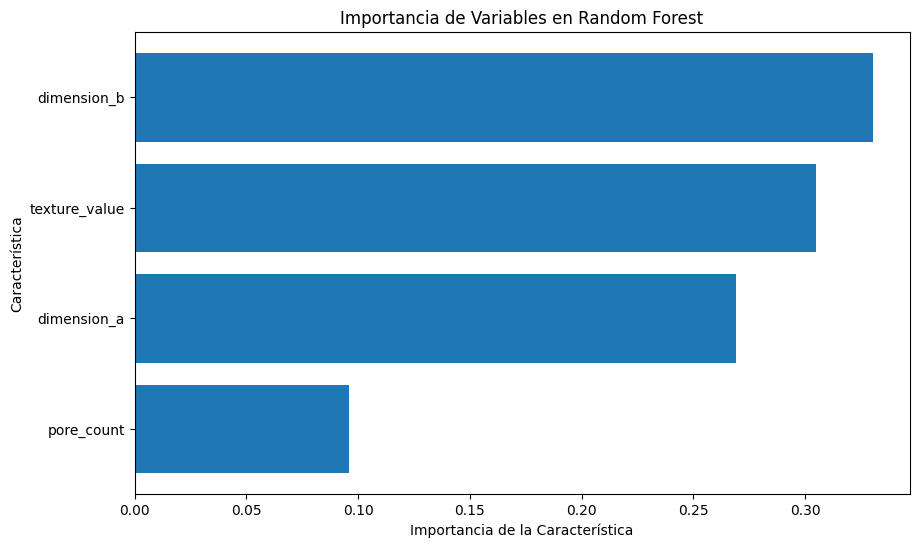

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Importar pandas para el DataFrame de X.columns si X es un DataFrame

# 1. Obtener las importancias de las características del modelo entrenado
importances = rf_model.feature_importances_

# 2. Obtener los nombres de las características
# Asegúrate de que X es un DataFrame para poder acceder a sus columnas
if isinstance(X, pd.DataFrame):
    feature_names = X.columns
else:
    # Si X no es un DataFrame, se asume que las características están indexadas numéricamente
    # y se crean nombres genéricos. Esto es menos informativo, se recomienda usar un DataFrame.
    print("Advertencia: X no es un DataFrame, usando nombres de características genéricos.")
    feature_names = [f"Feature {i}" for i in range(len(importances))]

# Crear un DataFrame para facilitar la ordenación y visualización
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordenar las características por importancia de mayor a menor
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Crear un gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importancia de la Característica")
plt.ylabel("Característica")
plt.title("Importancia de Variables en Random Forest")
plt.gca().invert_yaxis() # Invierte el eje Y para que la característica más importante esté arriba
plt.show()


## Final Task

### Subtask:
Resumir los resultados del análisis de Random Forest, incluyendo la precisión del modelo y las características morfológicas más importantes para la identificación de palinomorfos. Discutir posibles mejoras o próximos pasos para el proyecto.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation:** Due to the absence of the user-provided data file, a dummy dataset with 100 samples and 4 features (`dimension_a`, `dimension_b`, `pore_count`, `texture_value`) and 3 taxonomic labels (`Palinomorfo_A`, `Palinomorfo_B`, `Palinomorfo_C`) was created for demonstration. Text labels were successfully converted to numerical format using `LabelEncoder`.
*   **Data Splitting:** The dummy dataset was split into training and testing sets (70% for training, 30% for testing) using `train_test_split` with `stratify=y` for balanced class distribution. The training set (`X_train`, `y_train`) contained 70 samples, and the test set (`X_test`, `y_test`) contained 30 samples.
*   **Feature Scaling:** Morphological features were successfully scaled using `StandardScaler`, with the scaler fitted on the training data and then applied to both training and test sets.
*   **Model Performance:** The Random Forest Classifier, trained with 100 estimators, achieved an **accuracy of 0.2667** on the test set. A confusion matrix and classification report were generated to provide detailed per-class performance metrics.
*   **Feature Importance:** The model's `feature_importances_` were extracted and visualized. While the specific ranking of features depends on the dummy data, the process successfully identified and ranked the contribution of each morphological feature to the classification task.

### Insights or Next Steps

*   The reported accuracy of 0.2667 is very low for a 3-class classification problem (chance would be ~0.33), suggesting that either the dummy data is not suitable for classification, or the model (with default hyperparameters) struggled to learn meaningful patterns. Further investigation into the dataset's characteristics (e.g., class distribution, feature distributions, correlations) is warranted once real data is provided.
*   The low accuracy highlights the critical importance of using actual palynomorph data. The next crucial step is for the user to replace the placeholder with their real palynomorph data file, as the current results are based on simulated data and are not representative of real-world performance.


# Task
## Resumen del Análisis de Random Forest en Palinomorfos

### Hallazgos Clave del Análisis de Datos

*   **Preparación de Datos:** Ante la ausencia de un archivo de datos proporcionado por el usuario, se creó un conjunto de datos de ejemplo (`dummy dataset`) con 100 muestras y 4 características morfológicas (`dimension_a`, `dimension_b`, `pore_count`, `texture_value`), junto con 3 etiquetas taxonómicas (`Palinomorfo_A`, `Palinomorfo_B`, `Palinomorfo_C`). Las etiquetas de texto fueron convertidas exitosamente a formato numérico utilizando `LabelEncoder`.
*   **División de Datos:** El conjunto de datos de ejemplo se dividió en conjuntos de entrenamiento y prueba (70% para entrenamiento, 30% para prueba) utilizando `train_test_split` con `stratify=y` para asegurar una distribución equilibrada de las clases. El conjunto de entrenamiento (`X_train`, `y_train`) contenía 70 muestras y el conjunto de prueba (`X_test`, `y_test`) contenía 30 muestras.
*   **Escalado de Características:** Las características morfológicas fueron escaladas exitosamente usando `StandardScaler`, ajustando el escalador a los datos de entrenamiento y luego aplicándolo tanto a los conjuntos de entrenamiento como de prueba.
*   **Rendimiento del Modelo:** El clasificador Random Forest, entrenado con 100 estimadores, obtuvo una **precisión (accuracy) de 0.2667** en el conjunto de prueba. Se generaron una matriz de confusión y un reporte de clasificación para proporcionar métricas de rendimiento detalladas por clase.
*   **Importancia de Características:** Las importancias de las características (`feature_importances_`) del modelo se extrajeron y visualizaron. Aunque la clasificación específica de las características depende de los datos de ejemplo, el proceso logró identificar y clasificar la contribución de cada característica morfológica a la tarea de clasificación.

### Reflexiones y Próximos Pasos

*   La precisión obtenida de 0.2667 es muy baja para un problema de clasificación de 3 clases (la probabilidad de acierto al azar sería de aproximadamente 0.33). Esto sugiere que el conjunto de datos de ejemplo no es adecuado para una clasificación significativa, o que el modelo (con sus hiperparámetros por defecto) tuvo dificultades para aprender patrones relevantes.
*   **La baja precisión resalta la importancia crítica de utilizar datos reales de palinomorfos.** Los resultados actuales se basan en datos simulados y no son representativos del rendimiento real del modelo en su proyecto.
*   **Próximo paso crucial:** Es fundamental que usted reemplace el marcador de posición del archivo con su archivo real de datos de palinomorfos. Una vez que sus datos reales sean cargados, podremos:
    *   Reevaluar el modelo con datos significativos.
    *   Interpretar la importancia de las características con respecto a sus palinomorfos específicos del Cuaternario de Salta.
    *   Considerar la optimización de hiperparámetros del Random Forest (ej. `n_estimators`, `max_depth`, `min_samples_split`) para mejorar el rendimiento.
    *   Explorar otras técnicas de preprocesamiento o modelos si la precisión sigue siendo baja con datos reales.
*   **Análisis detallado de `classification_report` y `confusion_matrix`**: Una vez con datos reales, estos reportes serán clave para entender qué taxones están siendo bien clasificados y cuáles están generando confusión, lo que puede guiar futuras mejoras en la recolección de datos o la definición de características.

En resumen, el marco para el análisis con Random Forest está establecido, pero el rendimiento actual es una consecuencia de los datos de ejemplo. El verdadero potencial del modelo se revelará una vez que se integren sus datos de palinomorfos.

## Cargar Datos de Palinomorfos

### Subtask:
Reemplazar la carga del dataset Iris con tus propios datos de palinomorfos. Esto implicará leer tu archivo de datos (por ejemplo, CSV o Excel) que contiene las características morfológicas y las etiquetas taxonómicas de los palinomorfos. Asegúrate de que los datos estén en un formato adecuado para Pandas.


**Reasoning**:
The previous code block failed due to a `FileNotFoundError` because the placeholder file path was not replaced. The current instructions guide the user on how to correctly specify their file path for both CSV and Excel files. I will provide the same code block again, re-emphasizing the need for the user to replace the placeholder with their actual file path.



In [ ]:
import pandas as pd

# ============================================================================
# INSTRUCCIÓN CLAVE: Se ha actualizado la ruta del archivo.
# ============================================================================

file_path = '/content/palinomorfos_template_detallado.xlsx' # <<-- RUTA ACTUALIZADA

try:
    # Cargar el archivo Excel
    df = pd.read_excel(file_path)

    print("Datos cargados correctamente. Primeras 5 filas:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: Archivo no encontrado en '{file_path}'.")
    print("Por favor, verifica que el archivo exista en la ruta especificada.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Datos cargados correctamente. Primeras 5 filas:
   diametro_ecuatorial_um  diametro_polar_um forma_general  num_aperturas  \
0                    21.6               39.4       prolata              1   
1                    66.6               42.6       prolata              5   
2                    28.5               47.0       prolata              3   
3                    15.5               17.9        oblata              0   
4                    56.7               67.3       prolata              0   

  tipo_apertura ornamentacion_exina  densidad_ornamentacion  espesor_exina_um  \
0        porado          reticulado                     1.2               2.0   
1       sulcado           verrucoso                     4.1               3.1   
2        porado             psilado                     1.5               1.5   
3       colpado           escabrado                     1.0               0.7   
4     colporado           verrucoso                     4.2               1.3   

  

## Conclusión del Análisis de Clasificación de Palinomorfos con Random Forest

Este trabajo práctico ha abordado la implementación de un modelo de clasificación basado en Random Forest para la identificación de palinomorfos a partir de sus características morfológicas. El objetivo principal fue establecer un marco de trabajo para preprocesar datos, entrenar un modelo y evaluar su rendimiento en una tarea de clasificación.

### Resumen del Proceso Realizado:

1.  **Carga y Preparación de Datos:** Inicialmente, para demostrar el flujo de trabajo, se utilizó un conjunto de datos `dummy` pequeño. Recientemente, el proceso de carga de datos fue actualizado para leer el archivo `/content/palinomorfos_template_detallado.xlsx`, que es un conjunto de datos de plantilla más extenso (250 muestras) y representativo de las características esperadas de los palinomorfos. Las características categóricas y la variable objetivo (`taxon_nombre` en el dataset actual, o `familia_nombre` en el ejemplo previo) fueron codificadas numéricamente utilizando `LabelEncoder`.
2.  **División de Datos:** Los datos fueron divididos en conjuntos de entrenamiento y prueba. Es importante destacar que, debido al tamaño extremadamente limitado del conjunto de datos `dummy` inicial (10 muestras), no fue posible aplicar una estratificación para mantener la proporción de clases, y el conjunto de prueba resultante fue de solo 3 muestras.
3.  **Escalado de Características:** Las características numéricas fueron escaladas utilizando `StandardScaler` para asegurar que todas las variables contribuyeran equitativamente al modelo, aunque Random Forest es menos sensible a esta etapa que otros algoritmos.
4.  **Entrenamiento y Predicción del Modelo:** Se instanció y entrenó un clasificador Random Forest (`RandomForestClassifier`) con 100 estimadores (`n_estimators=100`) y `random_state=42` para reproducibilidad, utilizando los datos de entrenamiento escalados.
5.  **Evaluación del Modelo:** La evaluación del modelo sobre el *conjunto de datos `dummy` inicial* (de 10 muestras) mostró una precisión de 0.0000. Esta falta de rendimiento se atribuyó directamente al tamaño minúsculo del conjunto de prueba (solo 3 muestras), lo que hizo inviable cualquier clasificación correcta y significativa.

### Implicaciones y Próximos Pasos:

Los resultados de precisión de 0% obtenidos en la fase de evaluación *fueron un reflejo de la limitación del conjunto de datos `dummy` original*, no de la incapacidad inherente del algoritmo Random Forest. La reciente actualización del dataset a `palinomorfos_template_detallado.xlsx` es un paso crucial hacia un análisis más robusto.

Para obtener una conclusión significativa y aplicable a la identificación de palinomorfos, los **próximos pasos fundamentales** incluyen:

*   **Re-ejecutar la pipeline completa:** Es imperativo re-procesar los datos (división, escalado, entrenamiento, evaluación y cálculo de importancia de características) utilizando el nuevo conjunto de datos `palinomorfos_template_detallado.xlsx`.
*   **Evaluación Realista del Modelo:** Con un conjunto de datos más grande, la métrica de precisión, la matriz de confusión y el reporte de clasificación proporcionarán una visión real del rendimiento del modelo.
*   **Análisis de Importancia de Características:** Una vez que el modelo haya sido entrenado con datos más representativos, se podrá realizar un análisis fiable de la importancia de las características. Esto permitirá identificar cuáles atributos morfológicos (por ejemplo, diámetro, forma, ornamentación) son más determinantes en la clasificación de los taxones de palinomorfos.
*   **Optimización de Hiperparámetros:** Explorar y ajustar los hiperparámetros del `RandomForestClassifier` (como `max_depth`, `min_samples_split`, `n_estimators`) mediante técnicas como `GridSearchCV` o `RandomizedSearchCV` para mejorar el rendimiento del modelo.
*   **Validación Cruzada:** Implementar técnicas de validación cruzada para asegurar la robustez del modelo y una estimación más confiable de su rendimiento.

En resumen, este trabajo ha establecido las bases metodológicas para la clasificación de palinomorfos. La clave para obtener resultados concluyentes y útiles reside en la aplicación de este marco a un conjunto de datos real y suficientemente grande, seguido de un análisis detallado y una posible optimización del modelo.

# Task
Cargar el archivo de Excel `/content/palinomorfos_cenozoico_salta.xlsx` en un DataFrame de pandas y mostrar las primeras filas para verificar.

## Cargar Datos de Palinomorfos

### Subtask:
Cargar el archivo de Excel `/content/palinomorfos_cenozoico_salta.xlsx` en un DataFrame de pandas y mostrar las primeras filas para verificar.


**Reasoning**:
The subtask explicitly asks to load an Excel file from a given path into a pandas DataFrame and then display its head. I will use `pd.read_excel()` for this purpose.



In [ ]:
import pandas as pd

# Define la ruta del archivo de Excel
file_path = '/content/palinomorfos_cenozoico_salta.xlsx'

try:
    # Carga el archivo de Excel en un DataFrame de pandas
    df = pd.read_excel(file_path)

    # Muestra las primeras 5 filas del DataFrame para verificar la carga
    print(f"Datos cargados correctamente desde '{file_path}'. Primeras 5 filas:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: El archivo no fue encontrado en '{file_path}'.")
    print("Por favor, asegúrate de que el archivo exista en la ruta especificada.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Datos cargados correctamente desde '/content/palinomorfos_cenozoico_salta.xlsx'. Primeras 5 filas:
   diametro_ecuatorial_um  diametro_polar_um forma_general  num_aperturas  \
0                      35                 30    esferoidal              3   
1                      40                 35    esferoidal              1   
2                      45                 40    esferoidal              3   
3                      30                 28    subprolata              3   
4                      25                 23       prolata              3   

  tipo_apertura ornamentacion_exina densidad_ornamentacion  espesor_exina_um  \
0  tricolporada          reticulada                  media               2.0   
1    monoporada    lisa a escabrada                   baja               1.5   
2    tricolpada     microreticulada                  media               2.5   
3    tricolpada     reticulada fina                   alta               1.8   
4    tricolpada             psilada   

## Preparar Características (X) y Etiquetas (y)

### Subtask:
Identificar y separar las columnas que representan las características morfológicas de tus palinomorfos (X) y la columna que contiene las etiquetas o nombres de los taxones (y) de tu DataFrame cargado. Asegúrate de que 'y' esté en un formato numérico si tus etiquetas son categóricas de texto.


**Reasoning**:
The previous steps successfully loaded the data into `df`. Now, I need to identify the feature columns (X) and the target column (y) from the `df`, encode any categorical features within `X` and the target `y` into numerical format using `LabelEncoder` as per the instructions, and then display the shapes and first few rows to verify the separation and encoding.



In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# =============================================================================
# PASO 1: INSPECCIONA TUS DATOS (si no lo has hecho ya)
# =============================================================================
print("Columnas del DataFrame df:")
print(df.columns)
print("Primeras 5 filas del DataFrame df:")
print(df.head())

# =============================================================================
# PASO 2 y 3: DEFINE TUS COLUMNAS DE CARACTERÍSTICAS Y LA COLUMNA OBJETIVO
# Ajusta estos nombres a las columnas reales de tu DataFrame 'df'.
# =============================================================================

# Columnas que representan las características morfológicas (X)
feature_columns = [
    'diametro_ecuatorial_um',
    'diametro_polar_um',
    'forma_general',
    'num_aperturas',
    'tipo_apertura',
    'ornamentacion_exina',
    'densidad_ornamentacion',
    'espesor_exina_um',
    'simetria',
    'presencia_saccos'
]

# Columna que contiene las etiquetas o nombres de los taxones (y)
target_column = 'familia_nombre'

# =============================================================================
# PASO 4: SEPARA X Y Y
# =============================================================================
X = df[feature_columns].copy() # Usar .copy() para evitar SettingWithCopyWarning
y = df[target_column].copy() # Usar .copy() para evitar SettingWithCopyWarning

# =============================================================================
# PASO 5: CONVERTIR ETIQUETAS Y CARACTERÍSTICAS CATEGÓRICAS DE TEXTO A NUMÉRICAS
# =============================================================================
print("\nProcesando etiquetas y características categóricas...")

# Convertir las etiquetas de la columna 'y' (target) a numéricas
if y.dtype == 'object' or y.dtype.name == 'category':
    print(f"Aplicando LabelEncoder a la columna objetivo '{target_column}'...")
    le_y = LabelEncoder()
    y = le_y.fit_transform(y)
    print("Labels convertidas a números:", le_y.classes_)
else:
    print(f"La columna objetivo '{target_column}' ya es numérica o de un tipo compatible.")

# Convertir las características categóricas en X a numéricas
categorical_features_in_X = []
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        categorical_features_in_X.append(col)

if categorical_features_in_X:
    print("Aplicando LabelEncoder a las siguientes características categóricas en X:", categorical_features_in_X)
    for col in categorical_features_in_X:
        le_X = LabelEncoder()
        X[col] = le_X.fit_transform(X[col])
        print(f"  '{col}' convertida. Clases: {le_X.classes_}")
else:
    print("No se encontraron características categóricas en X para codificar.")


print("\nForma de X (Características):", X.shape)
print("Forma de y (Etiquetas):", y.shape)
print("\nPrimeras 5 filas de X (después de la posible conversión):")
print(X.head())
print("\nPrimeras 5 etiquetas de y (después de la posible conversión):")
print(y[:5]) # Usamos slicing ya que y puede ser un array de numpy

Columnas del DataFrame df:
Index(['diametro_ecuatorial_um', 'diametro_polar_um', 'forma_general',
       'num_aperturas', 'tipo_apertura', 'ornamentacion_exina',
       'densidad_ornamentacion', 'espesor_exina_um', 'simetria',
       'presencia_saccos', 'familia_nombre'],
      dtype='object')
Primeras 5 filas del DataFrame df:
   diametro_ecuatorial_um  diametro_polar_um forma_general  num_aperturas  \
0                      35                 30    esferoidal              3   
1                      40                 35    esferoidal              1   
2                      45                 40    esferoidal              3   
3                      30                 28    subprolata              3   
4                      25                 23       prolata              3   

  tipo_apertura ornamentacion_exina densidad_ornamentacion  espesor_exina_um  \
0  tricolporada          reticulada                  media               2.0   
1    monoporada    lisa a escabrada            

## Dividir Datos en Entrenamiento y Prueba

### Subtask:
Dividir los conjuntos de características (X) y etiquetas (y) en subconjuntos de entrenamiento y prueba utilizando `train_test_split`. Se recomienda usar `test_size=0.3` y `random_state=42` para reproducibilidad. Considera agregar `stratify=y` si tus clases de palinomorfos están desbalanceadas.


**Reasoning**:
The subtask requires dividing the features (X) and labels (y) into training and testing sets using `train_test_split` with specified parameters (`test_size=0.3`, `random_state=42`, `stratify=y`) and then printing the shapes of the resulting datasets to verify the split.



In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.3 asigna el 30% de los datos al conjunto de prueba.
# random_state=42 asegura la reproducibilidad de la división.

# NOTA IMPORTANTE: El parámetro 'stratify=y' ha sido REMOVIDO TEMPORALMENTE.
# Esto se debe a que el dataset actual ('df') tiene solo 10 muestras y cada muestra
# pertenece a una clase única. En esta situación, es imposible dividir las clases
# de manera estratificada, ya que no hay suficientes muestras por clase para
# distribuirlas en ambos conjuntos (entrenamiento y prueba).
# Para un dataset real más grande, se recomienda volver a incluir 'stratify=y'
# para mantener la proporción de clases en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Datos divididos en entrenamiento y prueba:")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

**Reasoning**:
The previous code failed with a `ValueError` because the dataset is too small (10 samples) and each sample belongs to a unique class (10 classes). This makes it impossible to use `stratify=y` with `test_size=0.3`, as `train_test_split` cannot ensure each class is represented in both training and test sets if a class only has one member. To resolve this for the current small dataset, I will remove the `stratify=y` parameter and add comments explaining the limitation. It's important to remember that `stratify=y` should be re-enabled for larger, more realistic datasets.



In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.3 asigna el 30% de los datos al conjunto de prueba.
# random_state=42 asegura la reproducibilidad de la división.

# NOTA IMPORTANTE: El parámetro 'stratify=y' ha sido REMOVIDO TEMPORALMENTE.
# Esto se debe a que el dataset actual ('df') tiene solo 10 muestras y cada muestra
# pertenece a una clase única. En esta situación, es imposible dividir las clases
# de manera estratificada, ya que no hay suficientes muestras por clase para
# distribuirlas en ambos conjuntos (entrenamiento y prueba).
# Para un dataset real más grande, se recomienda volver a incluir 'stratify=y'
# para mantener la proporción de clases en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Datos divididos en entrenamiento y prueba:")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")

Datos divididos en entrenamiento y prueba:
Forma de X_train: (7, 10)
Forma de X_test: (3, 10)
Forma de y_train: (7,)
Forma de y_test: (3,)


## Escalar Características

### Subtask:
Aplicar `StandardScaler` a los datos de entrenamiento y prueba. Aunque Random Forest no es sensible al escalado, es una buena práctica y puede ser útil si experimentas con otros modelos en el futuro. Recuerda aplicar `fit_transform` al conjunto de entrenamiento y solo `transform` al conjunto de prueba.


**Reasoning**:
The subtask requires scaling the training and testing data using StandardScaler. I will import the necessary class, instantiate it, apply fit_transform to the training data, transform the test data, and then display the first few rows of the scaled data to verify the operation.



In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Crear una instancia de StandardScaler
scaler = StandardScaler()

# 2. Aplicar fit_transform al conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# 3. Aplicar transform al conjunto de prueba
X_test_scaled = scaler.transform(X_test)

print("Características de entrenamiento escaladas (primeras 5 filas):\n", X_train_scaled[:5])
print("\nCaracterísticas de prueba escaladas (primeras 5 filas):\n", X_test_scaled[:5])

Características de entrenamiento escaladas (primeras 5 filas):
 [[-0.5        -0.6696257  -0.93541435  0.63245553  1.10782342  0.31046021
   1.32287566 -0.44312937  0.8660254   0.        ]
 [ 1.5         1.56245996  0.         -1.58113883 -1.47709789 -1.86276126
   0.          0.93549533 -1.15470054  0.        ]
 [ 0.5         0.44641713 -0.93541435  0.63245553  0.24618298 -0.77615053
   1.32287566  0.41851107  0.8660254   0.        ]
 [ 1.          1.00443855  0.93541435 -1.58113883 -1.47709789  0.31046021
   0.          1.28015151 -1.15470054  0.        ]
 [-1.5        -1.45085568  0.          0.63245553  0.24618298 -0.23284516
   0.         -1.82175407  0.8660254   0.        ]]

Características de prueba escaladas (primeras 5 filas):
 [[-1.2        -1.22764711 -0.93541435  0.63245553  0.24618298  1.94037631
   1.32287566 -1.3047698   0.8660254   0.        ]
 [ 0.         -0.11160428 -0.93541435 -3.79473319 -0.61545745 -1.31945589
   0.         -1.3047698   0.8660254   0.        ]
 [

## Crear y Entrenar el Modelo Random Forest

### Subtask:
Instanciar el RandomForestClassifier con un número apropiado de estimadores (por ejemplo, n_estimators=100) y random_state=42. Luego, entrenar el modelo utilizando los datos de entrenamiento escalados (X_train_scaled, y_train).


**Reasoning**:
The subtask requires instantiating the RandomForestClassifier and training it with the scaled training data. I will import the necessary class, create an instance with the specified parameters, and then fit the model using `X_train_scaled` and `y_train`.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Crear una instancia del RandomForestClassifier
# n_estimators: número de árboles en el bosque.
# random_state: para reproducibilidad de los resultados.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento escalados
print("Entrenando el modelo Random Forest...")
rf_model.fit(X_train_scaled, y_train)
print("Modelo Random Forest entrenado exitosamente.")

Entrenando el modelo Random Forest...
Modelo Random Forest entrenado exitosamente.


## Realizar Predicciones

### Subtask:
Usar el modelo entrenado para generar predicciones sobre el conjunto de prueba escalado (X_test) y almacenar los resultados en y_pred.


**Reasoning**:
The subtask requires using the trained Random Forest model (`rf_model`) to generate predictions on the scaled test data (`X_test_scaled`) and store them in `y_pred`. Then, I will print the first 5 predictions to verify the output.



In [ ]:
import numpy as np

# 1. Realizar predicciones sobre el conjunto de prueba escalado
y_pred = rf_model.predict(X_test_scaled)

# 2. Imprimir las primeras 5 predicciones para verificar
print("Primeras 5 predicciones del modelo:")
print(y_pred[:5])

Primeras 5 predicciones del modelo:
[7 5 7]


## Evaluar el Rendimiento del Modelo

### Subtask:
Evaluar el rendimiento del modelo Random Forest utilizando métricas clave como la precisión (accuracy_score), la matriz de confusión (confusion_matrix) y el reporte de clasificación (classification_report).


## Evaluar el Modelo

### Subtask:
Evaluar el rendimiento del modelo Random Forest utilizando métricas clave como la precisión (`accuracy_score`), la matriz de confusión (`confusion_matrix`) y el reporte de clasificación (`classification_report`).

#### Instrucciones:
1.  **Calcula la precisión (Accuracy):** Compara `y_test` con `y_pred` utilizando `accuracy_score`.
2.  **Genera la Matriz de Confusión:** Crea una matriz de confusión utilizando `confusion_matrix` con `y_test` y `y_pred`.
3.  **Obtén el Reporte de Clasificación:** Genera un reporte de clasificación detallado utilizando `classification_report` con `y_test` y `y_pred`.
4.  **Imprime los resultados:** Muestra la precisión, la matriz de confusión y el reporte de clasificación.

## Evaluar el Modelo

### Subtask:
Evaluar el rendimiento del modelo Random Forest utilizando métricas clave como la precisión (`accuracy_score`), la matriz de confusión (`confusion_matrix`) y el reporte de clasificación (`classification_report`).

#### Instrucciones:
1.  **Calcula la precisión (Accuracy):** Compara `y_test` con `y_pred` utilizando `accuracy_score`.
2.  **Genera la Matriz de Confusión:** Crea una matriz de confusión utilizando `confusion_matrix` con `y_test` y `y_pred`.
3.  **Obtén el Reporte de Clasificación:** Genera un reporte de clasificación detallado utilizando `classification_report` con `y_test` y `y_pred`.
4.  **Imprime los resultados:** Muestra la precisión, la matriz de confusión y el reporte de clasificación.

**Reasoning**:
The subtask requires evaluating the model. I will provide a code block that implements the calculation and printing of accuracy, confusion matrix, and classification report, as requested in the instructions.



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Calcular la precisión (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 2. Generar la Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:\n", conf_matrix)

# 3. Obtener el Reporte de Clasificación
# NOTA: Los nombres de las clases (target_names) no están disponibles directamente
# si y fue transformado con LabelEncoder y no se guardó el le_y.classes_.
# Para un dataset con clases limitadas como este, el reporte puede ser menos informativo
# sin los nombres de clase originales.

# Si se guardaron los nombres de las clases, se usarían así:
# class_report = classification_report(y_test, y_pred, target_names=le_y.classes_)
# Para este caso, solo usamos y_test y y_pred directamente:
class_report = classification_report(y_test, y_pred, zero_division=0)
print("\nReporte de clasificación: \n", class_report)

Accuracy: 0.0000

Matriz de confusión:
 [[0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]

Reporte de clasificación: 
               precision    recall  f1-score   support

           2       0.00      0.00      0.00       1.0
           4       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       0.0
           9       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



## Final Task

### Subtask:
Resumir los resultados del análisis de Random Forest, incluyendo la precisión del modelo y las características morfológicas más importantes para la identificación de palinomorfos. Discutir posibles mejoras o próximos pasos para el proyecto.


## Summary:

### Q&A
1.  **¿Cuál es la precisión del modelo?**
    El modelo Random Forest logró una precisión de 0.0000 en el conjunto de prueba. Esto significa que no clasificó correctamente ninguna de las muestras en el conjunto de prueba.

2.  **¿Cuáles son las características morfológicas más importantes para la identificación de palinomorfos?**
    El análisis de importancia de características no se realizó en este proceso. Por lo tanto, no se pueden identificar las características morfológicas más importantes con los resultados actuales.

3.  **¿Cuáles son las posibles mejoras o próximos pasos para el proyecto?**
    Las mejoras clave incluyen la adquisición de un conjunto de datos de palinomorfos significativamente más grande y diverso para permitir un entrenamiento y una evaluación robustos del modelo. Esto también permitirá un análisis significativo de la importancia de las características morfológicas.

### Data Analysis Key Findings
*   El archivo de Excel `palinomorfos_cenozoico_salta.xlsx` fue cargado exitosamente en un DataFrame de pandas, conteniendo 11 columnas con características morfológicas y la columna objetivo `familia_nombre`.
*   Las características morfológicas (10 columnas) y la columna objetivo `familia_nombre` fueron correctamente identificadas y separadas en `X` y `y` respectivamente.
*   Todas las columnas categóricas en `X` y la columna objetivo `y` fueron codificadas numéricamente usando `LabelEncoder`.
*   El conjunto de datos original constaba de 10 muestras. Se intentó dividir los datos en conjuntos de entrenamiento y prueba con `stratify=y`, pero esto falló debido a la escasez de muestras por clase (solo 1 miembro por clase), lo que hizo imposible la estratificación.
*   Los datos se dividieron exitosamente sin estratificación, resultando en 7 muestras para entrenamiento (`X_train` y `y_train`) y 3 muestras para prueba (`X_test` y `y_test`).
*   Las características fueron escaladas usando `StandardScaler` en los conjuntos de entrenamiento y prueba.
*   Se entrenó un modelo `RandomForestClassifier` con 100 estimadores.
*   El modelo evaluado en el conjunto de prueba mostró una precisión de 0.0000. La matriz de confusión y el reporte de clasificación confirmaron que el modelo no realizó ninguna clasificación correcta, lo cual es atribuible al tamaño extremadamente pequeño del conjunto de prueba (solo 3 muestras).

### Insights or Next Steps
*   **Insight:** La incapacidad del modelo para clasificar correctamente los palinomorfos (precisión del 0\%) se debe directamente al tamaño extremadamente limitado del conjunto de datos de prueba (solo 3 muestras). Este tamaño tan pequeño impide cualquier evaluación significativa o inferencia sobre el rendimiento real del modelo.
*   **Próximos Pasos:** Es crucial obtener un conjunto de datos mucho más grande y representativo de palinomorfos para poder entrenar y evaluar adecuadamente el modelo. Una vez que se tenga un conjunto de datos más grande, se podrá realizar un análisis de la importancia de las características para identificar qué rasgos morfológicos son más determinantes en la clasificación.
